In [14]:
import json
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import numpy as np

In [15]:
%matplotlib widget

In [16]:
pd.set_option("mode.copy_on_write", True)

In [17]:
def load_json(path):
    with open(path) as fhand:
        return json.load(fhand)

In [18]:
def filter_spbnet_df(df):
    df.rename(columns={'Unnamed: 0': 'Model'}, inplace=True)
    df.dropna(inplace=True)
    df = df[~df.Metric.isin(['MSE', 'MAE (Relative Reduction)', 'MAE'])]
    df.set_index('Model', inplace=True)
    df.drop(columns='Metric', inplace=True)
    return df

In [19]:
pretty_labels = {
    # Models
    #'cgcnn': 'CGCNN (0.08M)',
    #'moformer': 'MOFormer (11.7M)',
    #'pmtransformer': 'PMTransformer (86M)',
    #'spbnet': 'SpbNet (153M)',
    #'intellipore': 'IntelliPore (0.86M)',
    'cgcnn': 'CGCNN',
    'moformer': 'MOFormer',
    'pmtransformer': 'PMTransformer',
    'spbnet': 'SpbNet',
    'intellipore': 'IntelliPore',
}

In [20]:
datasets = [
    'hmof', 'hmofheat', 'cof', 'ppn',
    'zeolite', 'c3h6c3h8coremof', 'ch4n2'
]

In [21]:
# Convert excel to dataframe
xl = pd.read_excel('/home/asarikas/databases/SpbNet/41467_2026_69245_MOESM3_ESM.xlsx', sheet_name=None)
spbnet_dfs = {ds: filter_spbnet_df(xl[ds]) for ds in datasets}

In [22]:
# Populate R2 of each model

base_models = ['cgcnn', 'moformer', 'pmtransformer', 'spbnet']
ckpt_path = 'from_experiments_pretrain_early_pretrain_lightning_logs_version_0_checkpoints_best.ckpt-to_'
r2_dict = {model: [] for model in base_models + ['intellipore']}

for ds in datasets:  # Temporary until all results are finished
    key = 'null' if ds != 'hmofheat' else '5000'
    for task in set([i.split('-to_')[-1] for i in os.listdir(f'../experiments/evaluate/benchmark/{ds}/')]):
        # Load results for each task
        json_path = f'../experiments/evaluate/benchmark/{ds}/{ckpt_path}{task}/results.json'
        results = load_json(json_path)
        
        r2_dict['intellipore'].append(results[key]['0']['test_R2Score'])
        
        for m in base_models:
            r2_dict[m].append(spbnet_dfs[ds].loc[m, task])

In [23]:
palette = sns.color_palette(palette='tab20')
sns.set_theme(style='darkgrid', palette='tab20')

## Performance vs model size

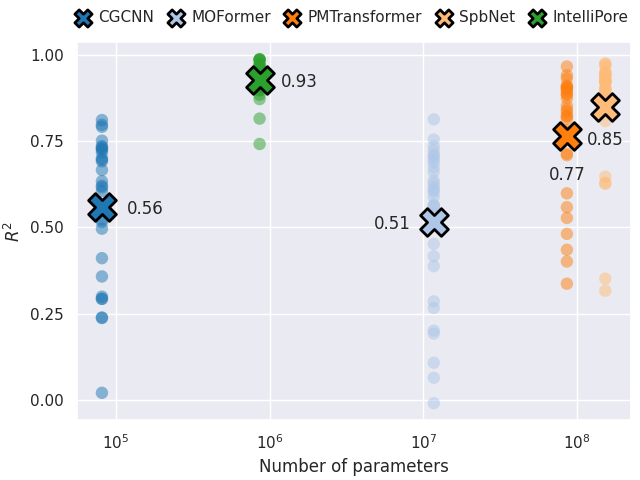

In [24]:
params_dict = {
    'cgcnn': [81e3, '81K'],
    'moformer': [11.7e6, '11.7M'],
    'pmtransformer': [86e6, '86M'],
    'spbnet': [153e6, '153M'],
    'intellipore': [0.86e6, '0.86M']
}

avg_r2_dict = {
    model: np.mean(r2_dict[model])
    for model in r2_dict.keys()
}

text_dict = {
    'cgcnn': [155e3, avg_r2_dict['cgcnn']],
    'moformer': [6.3e6, avg_r2_dict['moformer']],
    #'pmtransformer': [4.3e7, avg_r2_dict['pmtransformer']],
    'pmtransformer': [params_dict['pmtransformer'][0], avg_r2_dict['pmtransformer'] - 0.11],
    'spbnet': [params_dict['spbnet'][0], avg_r2_dict['spbnet'] - 0.09],
    #'spbnet': [1.1e8, avg_r2_dict['spbnet']],
    'intellipore': [1.57e6, avg_r2_dict['intellipore']],
}

palette = sns.color_palette('tab20', n_colors=len(params_dict))

fig, ax = plt.subplots(layout='constrained')

for i, model in enumerate(params_dict.keys()):

    color = palette[i]

    n_params = params_dict[model][0]
    r2_values = r2_dict[model]

    ax.scatter(
        [n_params] * len(r2_values),
        r2_values,
        s=80,
        alpha=0.5,
        edgecolor='none',
        color=color
    )

    ax.scatter(
        n_params,
        avg_r2_dict[model],
        label=pretty_labels[model],
        marker='X',
        s=400,
        linewidth=2,
        edgecolor='black',
        zorder=10,
        color=color
    )

    # optional text label
    coords = text_dict[model]
    ax.text(
        coords[0], coords[1],
        f'{avg_r2_dict[model]:.2f}',
        #transform=ax.transAxes,
        ha='center',
        va='center_baseline',
    )

ax.yaxis.set_major_locator(MaxNLocator(5))
ax.set_xscale('log')
ax.set_xlabel('Number of parameters')
ax.set_ylabel(r'$R^2$')
ax.grid(True)
ax.set_axisbelow(True)

leg = ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.49, 1.12),
    ncol=5,
    frameon=False,
    markerscale=0.62,
    handletextpad=0.02,
    columnspacing=0.4
)

for h in leg.legend_handles:
    try:
        h.set_markeredgewidth(0.7)
    except Exception:
        pass

plt.savefig('figures/r2_vs_size.pdf')
plt.show()